# Multi-Variable Boxplot Score Analysis

Box plots compare the spread and skewness of continuous numerical metrics across discrete groups. They highlight key summary statistics: minimum, first quartile (Q1), median (Q2), third quartile (Q3), maximum, and individual outliers. This notebook generates synthetic test scores across five study subjects and creates a styled Seaborn boxplot.



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Generate test scores across 5 subjects (1,200 students total)
np.random.seed(112)
n_students = 1200

subjects = np.random.choice(['Math', 'Physics', 'Chemistry', 'Biology', 'History'], size=n_students)
scores = []

# Inject varying score spreads and manual outliers per subject
for sub in subjects:
    if sub == 'Math':
        score = np.random.normal(72, 12)
    elif sub == 'Physics':
        score = np.random.normal(68, 14)
    elif sub == 'Chemistry':
        score = np.random.normal(75, 10)
    elif sub == 'Biology':
        score = np.random.normal(81, 8)
    else: # History
        score = np.random.normal(85, 6)
        
    scores.append(score)

scores = np.clip(scores, 10, 100)

df_students = pd.DataFrame({
    'Subject': subjects,
    'Score': scores
})

# Inject manual low-performing outlier scores to verify boxplot representation
outlier_indices = np.random.choice(n_students, size=18, replace=False)
df_students.loc[outlier_indices, 'Score'] = np.random.uniform(10, 30, 18)

df_students.head(10)



,Subject,Score
0,History,86.982633
1,Biology,78.136571
2,Math,68.453668
3,Chemistry,69.070695
4,Physics,54.413682
5,History,86.528231
6,History,86.043258
7,Math,58.600082
8,History,92.639758
9,Physics,81.378806


## Subject Aggregations

We calculate mean scores and count outliers (defined as values beyond 1.5 * IQR) to verify statistics.



In [2]:
stats = []
for sub, group in df_students.groupby('Subject'):
    q1, q3 = np.percentile(group['Score'], [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers_count = group[(group['Score'] < lower_bound) | (group['Score'] > upper_bound)].shape[0]
    
    stats.append({
        'Subject': sub,
        'Mean': group['Score'].mean(),
        'Median': group['Score'].median(),
        'Outliers': outliers_count
    })

df_stats = pd.DataFrame(stats)
print(f"Calculated Outliers Ratio: {df_stats['Outliers'].sum() / n_students * 100:.2f}%")
df_stats



Calculated Outliers Ratio: 1.75%


,Subject,Mean,Median,Outliers
0,Biology,80.945345,81.522690,3
1,Chemistry,72.727679,73.248025,7
2,History,84.378902,84.509581,1
3,Math,71.818257,72.092482,6
4,Physics,67.394338,67.672046,4


## Styled Subject Boxplots

Using Seaborn, we draw a vertical boxplot, coloring categories and formatting outlier points.



<cell>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<cell>:17: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



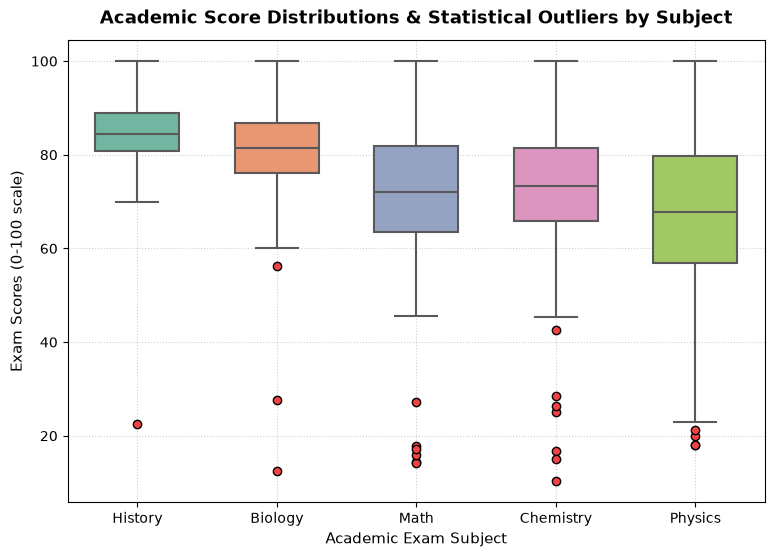

In [3]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    x='Subject', 
    y='Score', 
    data=df_students, 
    palette='Set2',
    width=0.6,
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='#EF4444', markersize=6, linestyle='none', markeredgecolor='black')
)

plt.title('Academic Score Distributions & Statistical Outliers by Subject', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Academic Exam Subject', fontsize=11)
plt.ylabel('Exam Scores (0-100 scale)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
